## 📍 Clustering Network Usage with DBSCAN
### 🎯 Objectives:
In this lab, we'll explore how to use DBSCAN (Density-Based Spatial Clustering of Applications with Noise) to identify clusters in `Network Usage` data.    
We will:
- Simulate network usage data
- Apply DBSCAN to detect clusters and noise points
- Visualize the clustering results using a scatter plot
- Count and report the number of clusters and noise points detected
- Evaluate DBSCAN performance





### Import Libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

### 🗂️ Data Loading & Preparation

In [20]:
# 1. Load dataset
df = pd.read_csv('network_usage_dataset.csv')
df.head()

,Session_Duration,Data_Usage_MB
0,96.572855,18.395445
1,306.635245,56.683297
2,209.904996,42.440529
3,88.086965,21.313107
4,296.099150,59.351163


In [21]:
df.isnull().sum()

Session_Duration    0
Data_Usage_MB       0
dtype: int64

### 🔷🔷🔷 Apply DBSCAN

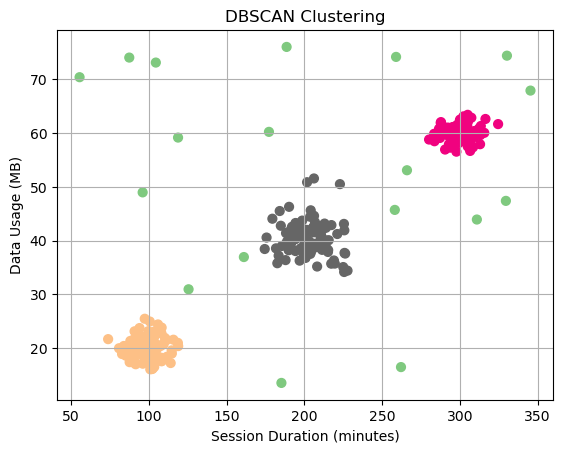

 Number of clusters: 3
 Number of noise 18


In [22]:
X = df[['Session_Duration', 'Data_Usage_MB']].values

# 2. Apply DBSCAN
model = DBSCAN(eps=10, min_samples=5) 
labels = model.fit_predict(X)
# [[0,0,0,0,1,1,1,2,2,-1]]

# 3. Plot the result
plt.scatter(X[:,0], X[:,1], c=labels, cmap='Accent', s=40) 

plt.title("DBSCAN Clustering")

plt.xlabel("Session Duration (minutes)")
plt.ylabel("Data Usage (MB)") 

plt.grid(True) 
plt.show()

num_clusters = len(set(labels)) - (1 if -1 in labels else 0) # [0,1,2,-1] -> 4 - 1 = 3
num_noise = list(labels).count(-1)

print(f" Number of clusters: {num_clusters}")
print(f" Number of noise {num_noise}")

### 🔍✅ Evaluate DBSCAN Performance

In [23]:
mask = labels != -1  # exclude noise points from score 

score = silhouette_score(X[mask], labels[mask]) 
print(f'Silhouette Score: {score}')


# X[mask] = [(1.0, 2.0), (1.5, 1.8), (5.0, 8.0), (1.2, 0.8)] (example.)
# labels[mask] [0, 0, 1, 0] (example.)

Silhouette Score: 0.8795887909709285


## 📌 Task1:
Try changing the Epsilon `eps` value to 5, run the code, and observe the difference in the clustering output.

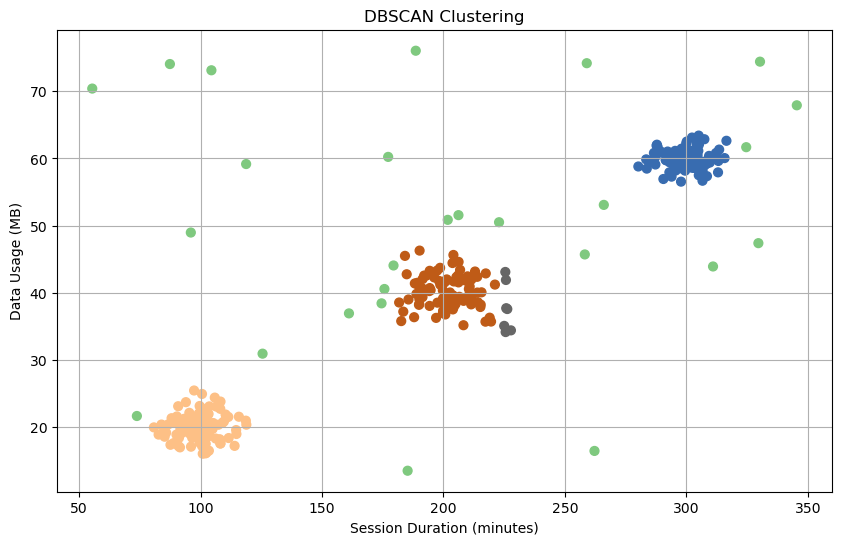

 Number of clusters: 4
 Number of noise 26
Silhouette Score: 0.7551323213413105


In [24]:
X = df[['Session_Duration', 'Data_Usage_MB']].values

# 2. Apply DBSCAN
model = DBSCAN(eps=5, min_samples=5)
labels = model.fit_predict(X)

# 3. Plot the result
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='Accent', s=40) 

plt.title("DBSCAN Clustering")

plt.xlabel("Session Duration (minutes)")
plt.ylabel("Data Usage (MB)") 

plt.grid(True)
plt.show()

num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
num_noise = list(labels).count(-1)

print(f" Number of clusters: {num_clusters}")
print(f" Number of noise {num_noise}")


mask = labels != -1  # exclude noise points from score

score = silhouette_score(X[mask], labels[mask]) 
print(f'Silhouette Score: {score}')

## 📌 Task2:
Build a DBSCAN model using the specified parameters below.
Then:
- Evaluate the model using Silhouette Score 🧮
- Compare the results with the previous configuration in terms of:
    - Number of clusters
    - Number of noise points
    - Silhouette score 📊

In [25]:
# To-Do: 

# 1. Apply DBSCAN with eps=18 and min_samples=10.

# 2. Plot the clustering result with fig size=(12, 8), using a scatter plot with cmap='tab10' and marker size 80.

# 3. Set appropriate axis labels and a title:
#    - Title: Network Usage Clustering
#    - X-axis: Minutes
#    - Y-axis: MB

# 4. Print the number of clusters and noise points.

# 5. Calculate Silhouette score.

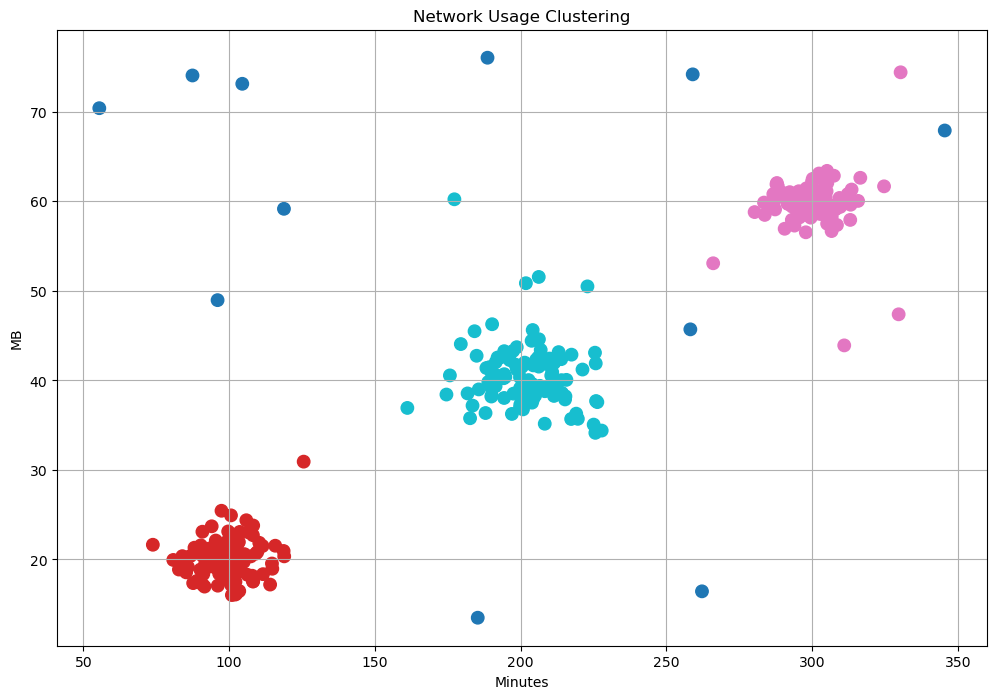

 Number of clusters: 3
 Number of noise 11
Silhouette Score: 0.8690588359197876


In [26]:
X = df[['Session_Duration', 'Data_Usage_MB']].values

# Apply DBSCAN
model = DBSCAN(eps=18, min_samples=10)
labels = model.fit_predict(X)

# Plot the result
plt.figure(figsize=(12,8))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='tab10', s=80) 

plt.title("Network Usage Clustering")

plt.xlabel("Minutes")
plt.ylabel("MB") 

plt.grid(True)
plt.show()

num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
num_noise = list(labels).count(-1)

print(f" Number of clusters: {num_clusters}")
print(f" Number of noise {num_noise}")


mask = labels != -1  # exclude noise points from score

score = silhouette_score(X[mask], labels[mask]) 
print(f'Silhouette Score: {score}')

## 🚀 Advanced DBSCAN with Multi-Feature Clustering


Project Concept

This prototype was built using synthetic (non-real) data designed specifically to test the performance of the DBSCAN clustering algorithm, which is commonly used for unsupervised anomaly detection based on data density.

Core Idea:

In this experiment, we simulate two types of users:
	•	Human user: Displays typical behavior, such as moderate visit times, reasonable number of page views, and average mouse movement.
	•	Bot: Exhibits extreme or abnormal behavior, such as very short visits, unusually high clicks, or erratic interaction patterns.

Objective:

To evaluate whether DBSCAN can distinguish between human users and bots by detecting patterns in the data without any prior labels (unsupervised learning).



Important Notes:
	•	The data used in this experiment is completely artificial and created for testing purposes only. It is not based on real user behavior.
	•	In real-world scenarios, it is common for:
	•	The human pattern to be dominant in the dataset.
	•	The bot behavior to appear as an outlier, significantly different from the general user behavior.
	•	In such cases, DBSCAN can effectively classify bots as “noise”, since they do not follow the same density or behavioral patterns as the majority.

## 1. Data Loading

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors

In [36]:
# Load the dataset
file_path = 'DBSCAN_bots_humans.csv'
df = pd.read_csv(file_path)

df.head()

,pages_visited,session_duration,clicks,javascript_enabled,device_type,mouse_movement,hour_of_visit,is_bot
0,10,323,16,1.0,desktop,1.0,14,0
1,4,207,15,1.0,mobile,1.0,13,0
2,6,267,10,1.0,mobile,1.0,18,0
3,20,69,54,0.0,desktop,0.0,1,1
4,2,272,11,1.0,desktop,1.0,22,0


## 2. Data Cleaning

In [37]:
# Drop rows that are completely empty
df.dropna(how='all', inplace=True)

# Fill missing values with the column mean
imputer = SimpleImputer(strategy='mean')
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols_to_impute = [col for col in numeric_cols if not df[col].isnull().all()]
df[numeric_cols_to_impute] = imputer.fit_transform(df[numeric_cols_to_impute])


print("\nCleaned dataset (after imputing missing values):")
print(df.describe())


Cleaned dataset (after imputing missing values):
       pages_visited  session_duration       clicks  javascript_enabled  \
count    1200.000000       1200.000000  1200.000000         1200.000000   
mean       12.329167        178.829167    32.370000            0.500000   
std         8.168930        125.609181    18.312406            0.500208   
min         0.000000         -6.000000     6.000000            0.000000   
25%         5.000000         59.000000    15.000000            0.000000   
50%        10.000000        142.500000    29.000000            0.500000   
75%        19.000000        296.000000    50.000000            1.000000   
max        34.000000        438.000000    73.000000            1.000000   

       mouse_movement  hour_of_visit       is_bot  
count     1200.000000    1200.000000  1200.000000  
mean         0.500000      12.996667     0.500000  
std          0.500208       5.884911     0.500208  
min          0.000000       0.000000     0.000000  
25%          0

## 3. Feature Selection and Scaling

In [38]:
features = ['session_duration', 'pages_visited', 'mouse_movement']
X = df[features]
y_true = df['is_bot'] # Ground truth

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # normalise them

## 4. Tune DBSCAN Parameters using K-distance graph (for eps)


Using min_samples = 6 (2 * number of features)


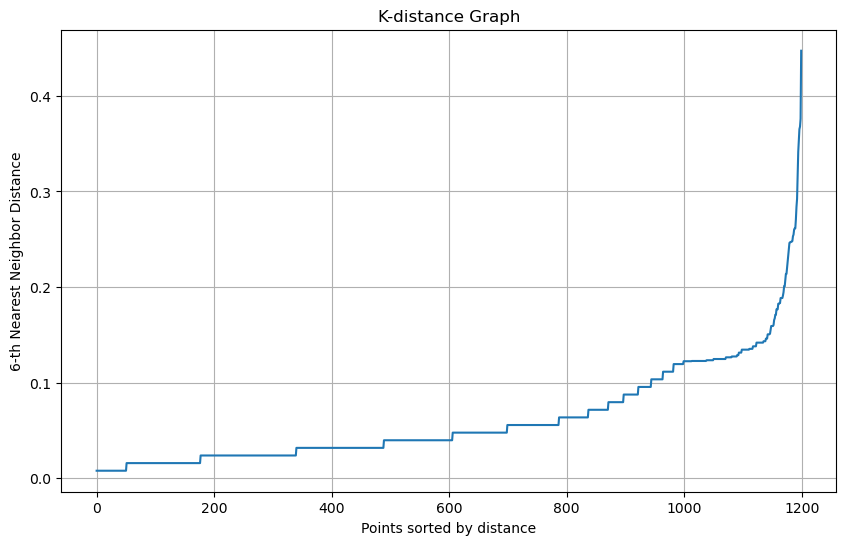


Observe the elbow point in the K-distance graph to determine the optimal 'eps' value.


In [39]:
# Find the best eps bt K-distance

# Determine min_samples (typically 2 * number of features)
min_samples = 2 * len(features) 
print(f"\nUsing min_samples = {min_samples} (2 * number of features)")

# Calculate the average distance of every point to its k-th nearest neighbor
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances and plot
distances = np.sort(distances[:, min_samples-1], axis=0)
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-distance Graph')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{min_samples}-th Nearest Neighbor Distance')
plt.grid(True)
plt.show()

print("\nObserve the elbow point in the K-distance graph to determine the optimal 'eps' value.") 

## 5. Apply DBSCAN with chosen parameters

In [40]:
chosen_eps = 0.2

## But from the K-distance Graph we see the esp value that we can use in our model [0.2, 0.15]
min_samples_adjusted = 12 # Increased min_samples
print(f"\nApplying DBSCAN with eps={chosen_eps} and min_samples={min_samples_adjusted}")

db = DBSCAN(eps=chosen_eps, min_samples=min_samples_adjusted).fit(X_scaled)
labels = db.labels_ # result of DBSCAN clustering [0, 1, 2, ... for clusters], [-1 for noise (outliers)]

# Assign labels to the DataFrame
df['cluster'] = pd.Series(labels, index=X.index)


Applying DBSCAN with eps=0.2 and min_samples=12


## 6. Evaluate Performance

In [41]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"\nNumber of clusters found by DBSCAN: {n_clusters}")
print(f"Number of noise points found by DBSCAN: {n_noise}")

# Separate noise and clustered points
noise_points_df = df[df['cluster'] == -1]
clustered_points_df = df[df['cluster'] != -1]



mask = labels != -1  # exclude noise points from score

score = silhouette_score(X[mask], labels[mask]) 
print(f"\nSilhouette Score: {score}")


Number of clusters found by DBSCAN: 2
Number of noise points found by DBSCAN: 25

Silhouette Score: 0.8318705740024501


## 7. Visualize the results

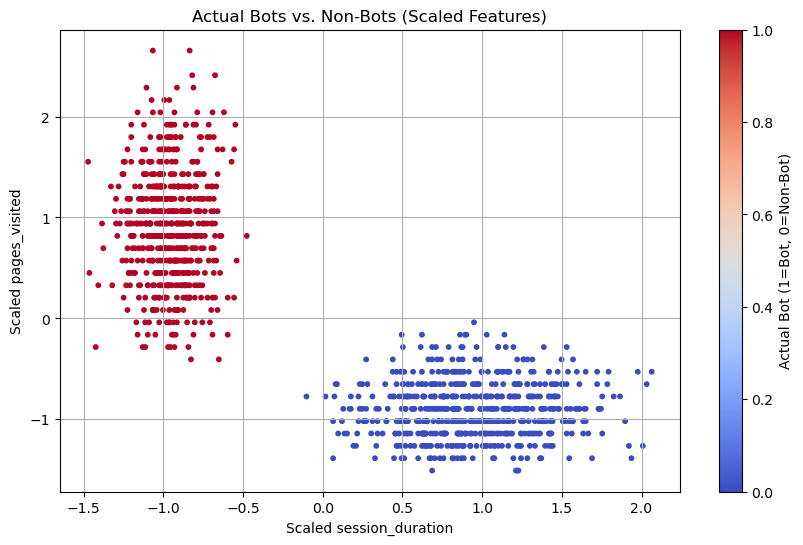

In [42]:
# Visualize actual bots vs. non-bots
plt.figure(figsize=(10, 6))
# Color points based on actual is_bot value
scatter_actual = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_true, cmap='coolwarm', s=10)
plt.title("Actual Bots vs. Non-Bots (Scaled Features)")
plt.xlabel(f"Scaled {features[0]}")
plt.ylabel(f"Scaled {features[1]}")
plt.colorbar(scatter_actual, label='Actual Bot (1=Bot, 0=Non-Bot)')
plt.grid(True)
plt.show()

# Second plot (Predicted Noise) previously removed

## 9. Analyze Feature Distributions

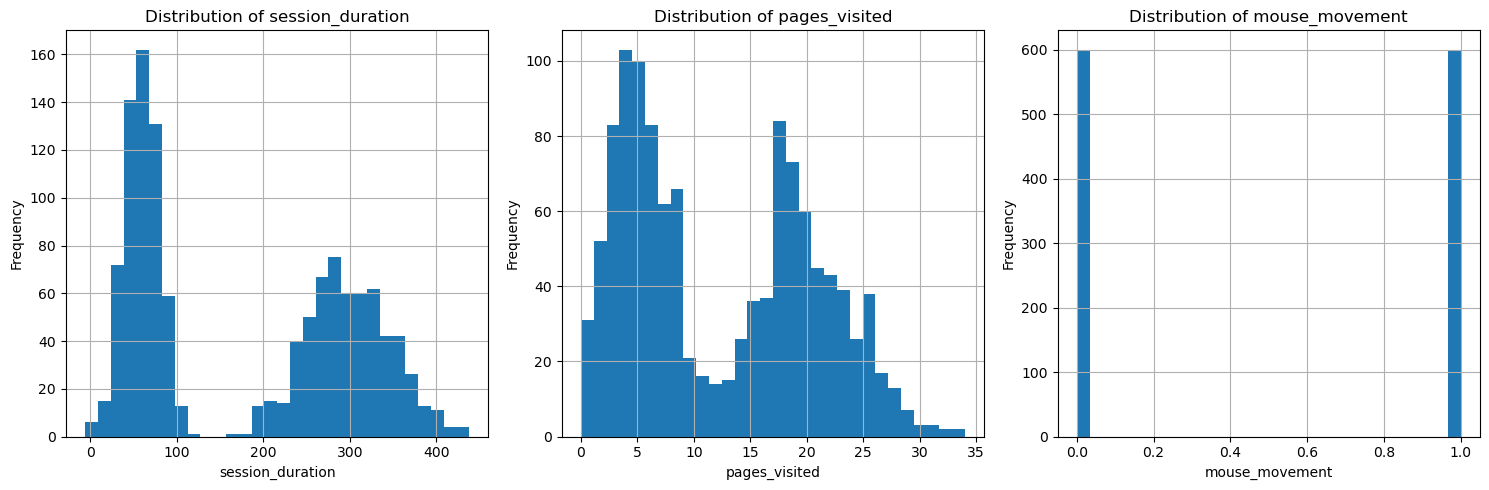

Observe the distribution of each feature to identify skewness or potential outliers.


In [43]:
# Analyze the distribution of the selected features
features_to_analyze = ['session_duration', 'pages_visited', 'mouse_movement']

plt.figure(figsize=(15, 5))

for i, feature in enumerate(features_to_analyze):
    plt.subplot(1, 3, i + 1)
    df[feature].hist(bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.grid(True)

plt.tight_layout()
plt.show()

print("Observe the distribution of each feature to identify skewness or potential outliers.")